# Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# For maps
import geopandas as gpd
import contextily as cx

# For autocorrelation
from statsmodels.graphics.tsaplots import plot_acf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Panel build up and check

In [55]:
# Station-hour panel parquet 

import pandas as pd

DATA_PATH = Path("../outputs/ecobici_station_hour.parquet")

df = pd.read_parquet(DATA_PATH)

print(df.shape)
print(df["year"].unique())
print(df["departures"].describe().round(2))
print(df["arrivals"].describe().round(2))

(22463807, 14)
[2018 2019 2020 2021 2022 2023 2024 2025]
count    22463807.00
mean            3.61
std             4.37
min             0.00
25%             1.00
50%             2.00
75%             5.00
max           335.00
Name: departures, dtype: float64
count    22463807.00
mean            3.60
std             4.49
min             0.00
25%             1.00
50%             2.00
75%             5.00
max           344.00
Name: arrivals, dtype: float64


- The typical station has 2.0 departures and arrivals per hour.
- The distribution is right-skewed: 75% of hourly observations have 5 or fewer trips.
- The max reaches 335 departures and 344 arrivals; a small number of stations pull the mean (3.61) above the median (2.0)

In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22463807 entries, 0 to 22463806
Data columns (total 14 columns):
 #   Column           Dtype         
---  ------           -----         
 0   station_id       int64         
 1   datetime_hour    datetime64[us]
 2   departures       int64         
 3   arrivals         int64         
 4   net_flow         int64         
 5   abs_net_flow     int64         
 6   year             int64         
 7   month            int64         
 8   day              int64         
 9   hour             int64         
 10  weekday          int64         
 11  is_weekend       int32         
 12  is_morning_peak  int32         
 13  is_evening_peak  int32         
dtypes: datetime64[us](1), int32(3), int64(10)
memory usage: 2.1 GB


In [57]:
df["departures"].sum(), 
df["arrivals"].sum()

np.int64(80839280)

In [58]:
# Total yearly departures and arrivals

yearly = df.groupby("year")[["departures", "arrivals"]].sum().reset_index()
print(yearly)

   year  departures  arrivals
0  2018     8540225   8540225
1  2019     8415401   8415400
2  2020     4031867   4031867
3  2021     4295406   4295406
4  2022     4821097   4812019
5  2023    10379150  10306856
6  2024    21256801  21177644
7  2025    19356074  19259863


# EDA pre feature engineering

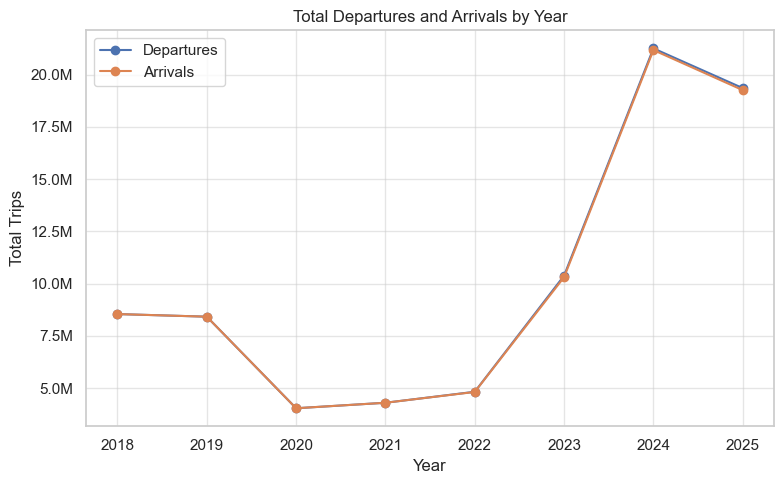

In [59]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(yearly["year"], yearly["departures"], marker="o", label="Departures")
ax.plot(yearly["year"], yearly["arrivals"], marker="o", label="Arrivals")

ax.set_title("Total Departures and Arrivals by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Total Trips")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend()
ax.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

In [60]:
target = "departures"

X = df.drop(columns=[target, "datetime_hour"])
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (22463807, 12)
y shape: (22463807,)


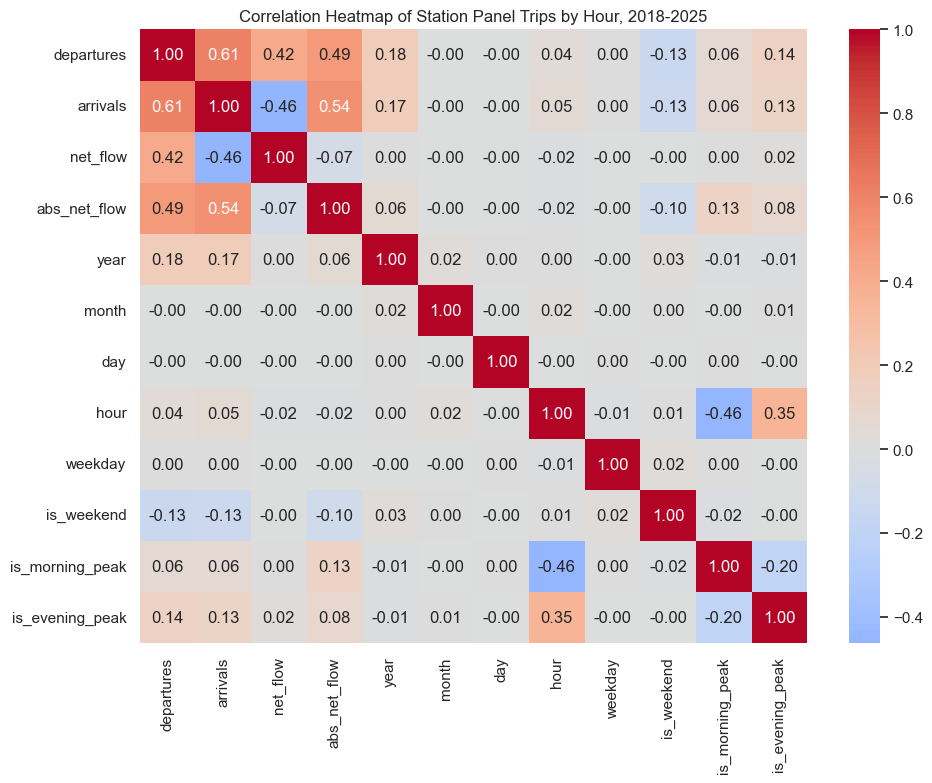

In [61]:
corr_cols = [
    "departures", "arrivals", "net_flow", "abs_net_flow",
    "year", "month", "day", "hour", "weekday",
    "is_weekend", "is_morning_peak", "is_evening_peak"
]

corr = df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Station Panel Trips by Hour, 2018-2025")
plt.tight_layout()
plt.show()

# Main correlation takeaways:
- departures and arrivals (0.61) - stations where people take bikes also receive a lot, which means they are hubs
- arrivals and net_flow (-0.46) - stations with high arrivals have a negative net flow (more bikes coming, so a surplus)
- hour and is_morning_peak (-0.46) - morning peak takes place at specific times (e.g. 9 am), so other hours will not show a correlation as time progresses during the day
- hour and is_evening_peak (0.35) - evening peak has higher hour values, so as hour increases we get closer to the evening peak

# Other insights:
- month, day, and weekday correlate with almost nothing, meaning that trip volume by station doesn't vary beacause of these
- year and departures (0.18) - these have a slight growth over time, could be related to the BSS growth
- is_weekend and departures (-0.13) - these could help explain the negative trips on weekends (e.g. commuters)

<Axes: xlabel='hour'>

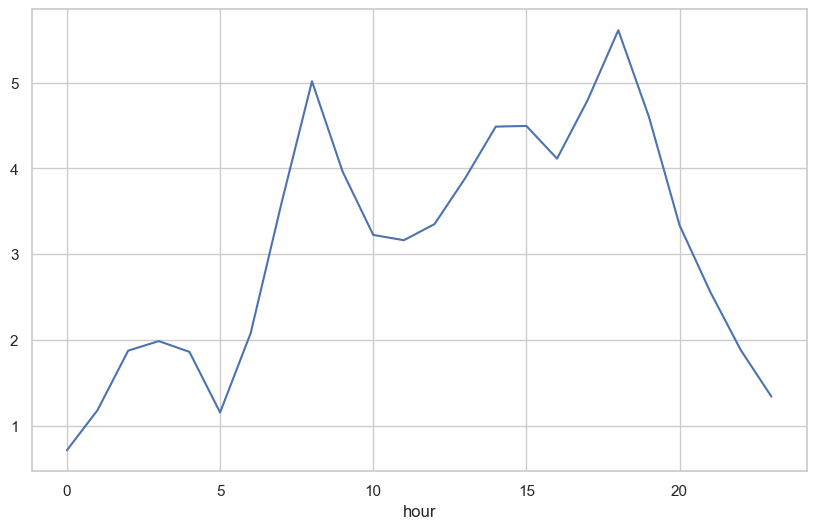

In [62]:
df.groupby("hour")["departures"].mean().plot()

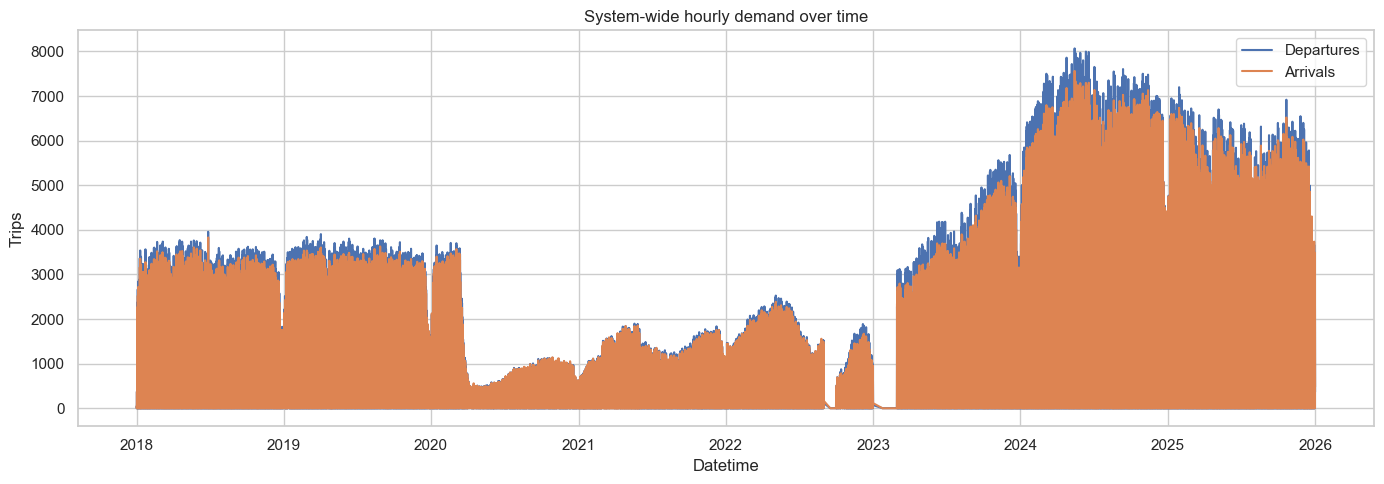

In [64]:
system_hourly = (
    df.groupby("datetime_hour")[["departures", "arrivals"]]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(system_hourly["datetime_hour"], system_hourly["departures"], label="Departures")
ax.plot(system_hourly["datetime_hour"], system_hourly["arrivals"], label="Arrivals")
ax.set_title("System-wide hourly demand over time")
ax.set_xlabel("Datetime")
ax.set_ylabel("Trips")
ax.legend()
plt.tight_layout()
plt.show()

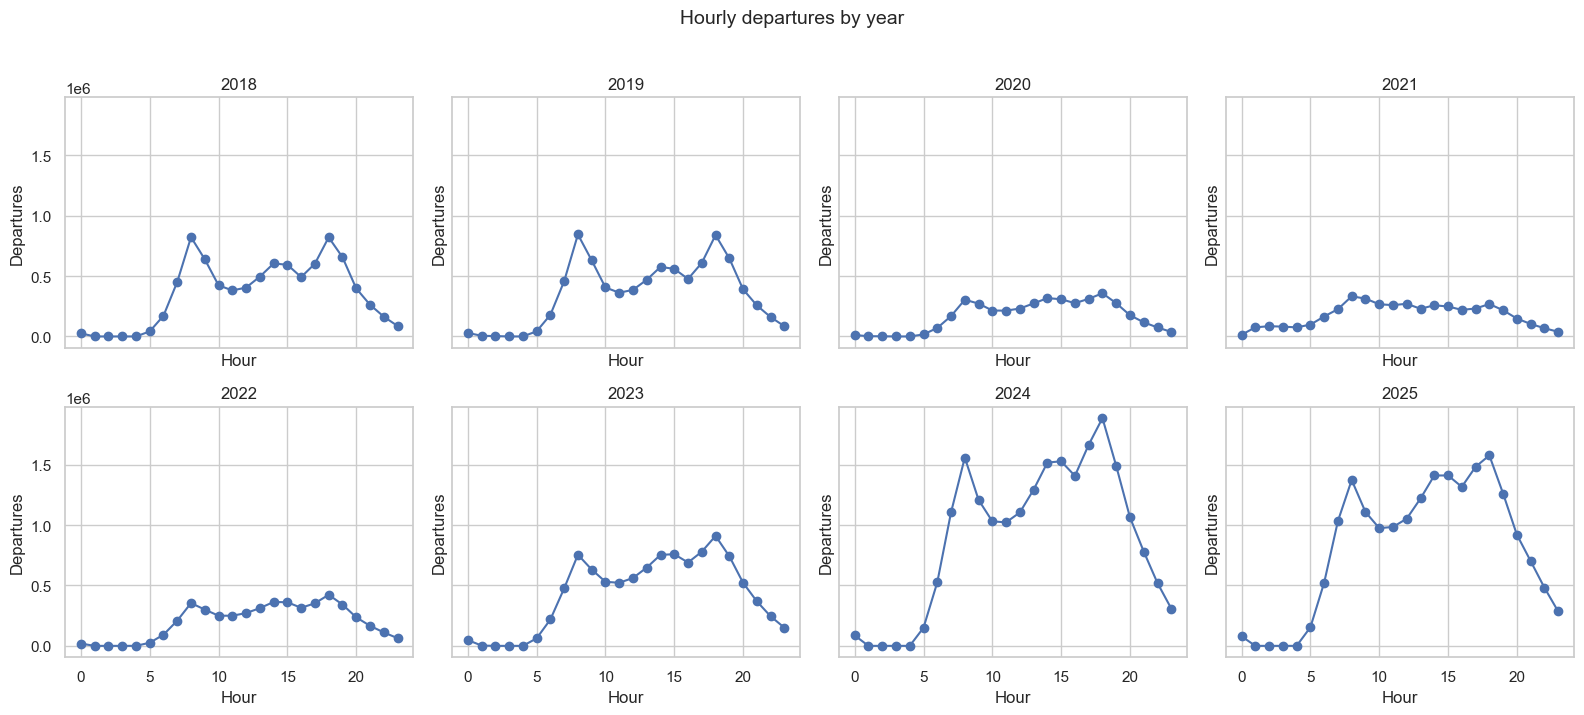

In [65]:
hourly_year = (
    df.groupby(["year", "hour"])["departures"]
    .sum()
    .reset_index()
)

years = sorted(hourly_year["year"].unique())
n = len(years)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

for i, yr in enumerate(years):
    temp = hourly_year[hourly_year["year"] == yr]
    axes[i].plot(temp["hour"], temp["departures"], marker="o")
    axes[i].set_title(str(yr))
    axes[i].set_xlabel("Hour")
    axes[i].set_ylabel("Departures")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Hourly departures by year", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

- Pre COVID-19, the hourly departures seem to cluster between 8-9 am and then peak again at 6-7 p.m.
- During COVID-19, activity falls across the board with minor peaks in those times but not consistent
- Post COVID-19, the hourly departures again cluster 8-9 a.m. and then peak again at 6-7 p.m., with a more pronounced curve and down fall in the afternoon

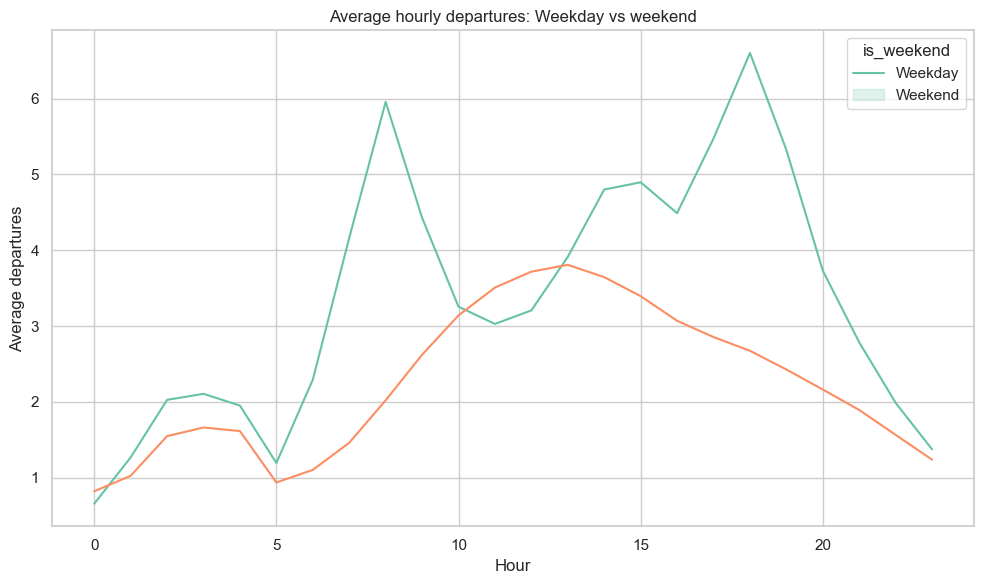

In [67]:
weekday_weekend = (
    df.groupby(["is_weekend", "hour"])["departures"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=weekday_weekend,
    x="hour",
    y="departures",
    hue="is_weekend",
    palette="Set2"
)
plt.title("Average hourly departures: Weekday vs weekend")
plt.xlabel("Hour")
plt.ylabel("Average departures")
plt.legend(title="is_weekend", labels=["Weekday", "Weekend"])
plt.tight_layout()
plt.show()

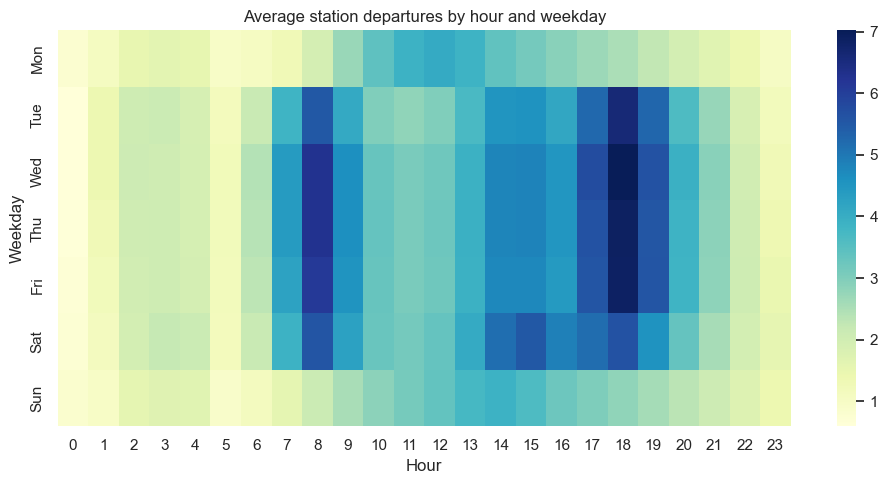

In [106]:
weekday_map = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu",
    4: "Fri", 5: "Sat", 6: "Sun"
}

temp = (
    df.groupby(["weekday", "hour"])["departures"]
    .mean()
    .reset_index()
)

pivot = temp.pivot(index="weekday", columns="hour", values="departures")
pivot.index = pivot.index.map(weekday_map)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, cmap="YlGnBu", annot=False)
plt.title("Average station departures by hour and weekday")
plt.xlabel("Hour")
plt.ylabel("Weekday")
plt.tight_layout()
plt.show()

<Axes: xlabel='hour'>

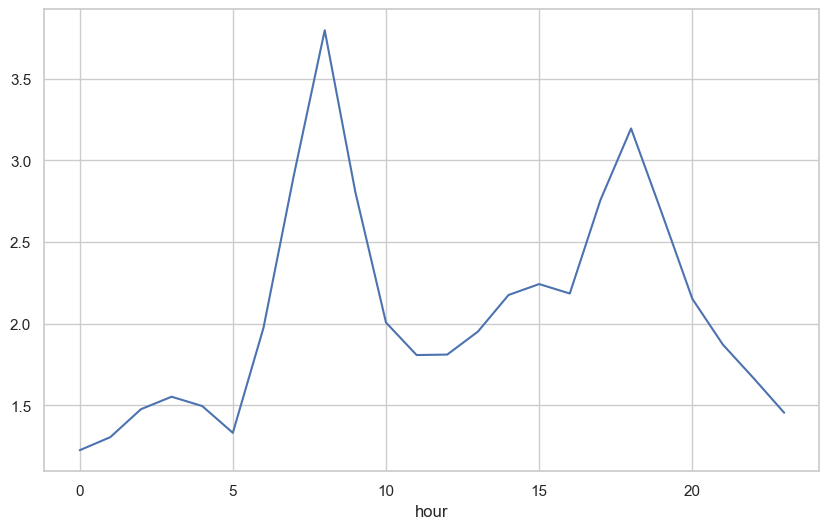

In [63]:
df.groupby("hour")["abs_net_flow"].mean().plot()

# Spatial distribution

In [77]:
# demand mapping

station_demand = (
    df.groupby("station_id")[["departures", "arrivals"]]
    .sum()
    .reset_index()
)

In [80]:
# imbalance mapping

station_imbalance = (
    df.groupby("station_id")[["net_flow", "abs_net_flow"]]
    .sum()
    .reset_index()
)

In [ ]:
# merge from 01_cdmx_GBFSstation_map.ipynb

stations_ref = pd.read_parquet("../data/reference/stations_gbfs_current.parquet")

stations_ref["station_id"] = stations_ref["station_id"].astype(str).str.strip()
station_demand["station_id"] = station_demand["station_id"].astype(str).str.strip()

station_demand = station_demand.merge(
    stations_ref[["station_id", "lat", "lon"]],
    on="station_id",
    how="left"
)


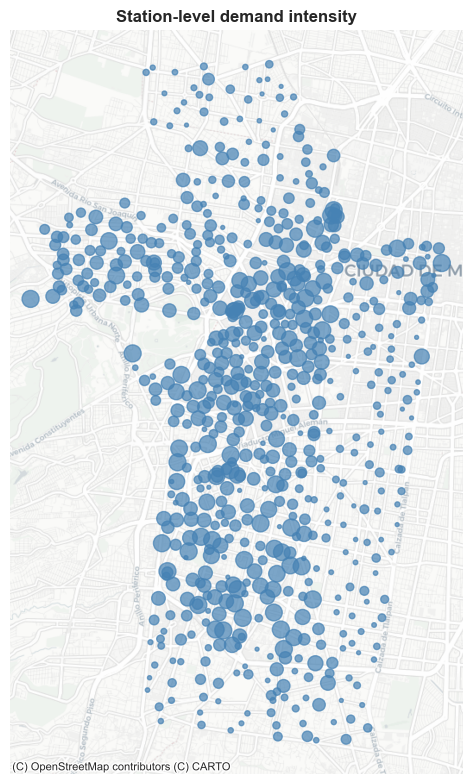

In [ ]:
demand_map = station_demand.dropna(subset=["lat", "lon"]).copy() # dropping stations that can't be mapped

gdf = gpd.GeoDataFrame(
    demand_map,
    geometry=gpd.points_from_xy(demand_map["lon"], demand_map["lat"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 8))

gdf.plot(
    ax=ax,
    markersize=np.clip(gdf["departures"] / gdf["departures"].quantile(0.95) * 150, 8, 150),
    alpha=0.7,
    color="steelblue"
)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title("Station-level demand intensity", fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [88]:
stations_ref["station_id"] = stations_ref["station_id"].astype(str).str.strip()
station_imbalance["station_id"] = station_imbalance["station_id"].astype(str).str.strip()

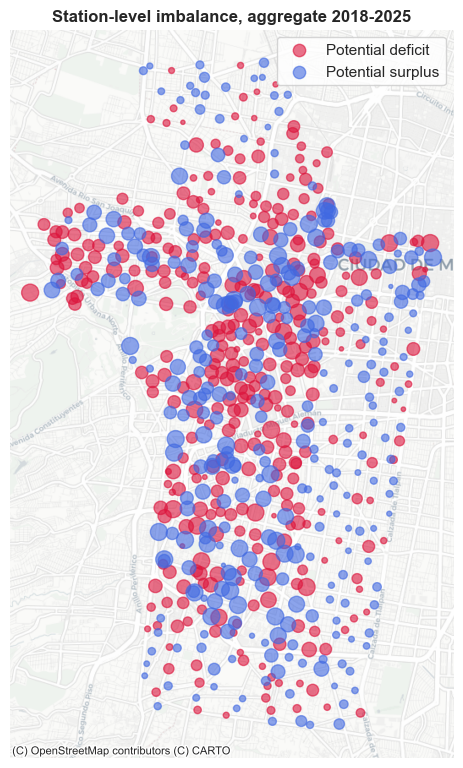

In [ ]:
# MAP2: Where has the imbalance been concentrated?

imbalance_map = station_imbalance.dropna(subset=["lat", "lon"]).copy()

# balanced net flow would be: net_flow = departures - arrivals 
# if net_flow > 0, it means the station is more likely to lose bikes (deficit)
# if net_flow < 0, it means the station is more likely to accumulate them (surplus)

imbalance_map["flow_direction"] = np.where(
    imbalance_map["net_flow"] > 0,
    "Potential deficit",
    np.where(imbalance_map["net_flow"] < 0, "Potential surplus", "Balanced")
)

gdf = gpd.GeoDataFrame(
    imbalance_map,
    geometry=gpd.points_from_xy(imbalance_map["lon"], imbalance_map["lat"]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

color_map = {
    "Potential deficit": "crimson",
    "Potential surplus": "royalblue",
    "Balanced": "gray"
}

fig, ax = plt.subplots(figsize=(8, 8))

for cat, group in gdf.groupby("flow_direction"):
    group.plot(
        ax=ax,
        markersize=np.clip(
            group["abs_net_flow"] / gdf["abs_net_flow"].quantile(0.95) * 150, #95th percentile
            8,
            150 #normalizes the values so that extreme stations do not dominate
        ),
        alpha=0.6,
        color=color_map[cat],
        label=cat
    )

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title("Station-level imbalance, aggregate 2018-2025", fontweight="bold")
ax.legend()
ax.set_axis_off()
plt.tight_layout()
plt.show()

- We can see the imbalance is largerly concentrated in the western/center part of the city
- This map does not tell us when the imbalance occurs, but that the stations with most need are fairly close to each

In [151]:
def plot_imbalance_timeperiod_ax(filtered_df, ax, title, stations_ref, global_scale=None):
    # aggregate by station
    station_imbalance = (
        filtered_df.groupby("station_id")[["net_flow", "abs_net_flow"]]
        .sum()
        .reset_index()
    )

    # merge coordinates
    station_imbalance["station_id"] = station_imbalance["station_id"].astype(str).str.strip()

    station_imbalance = station_imbalance.merge(
        stations_ref[["station_id", "lat", "lon"]],
        on="station_id",
        how="left"
    )

    # keep only rows with coordinates
    imbalance_map = station_imbalance.dropna(subset=["lat", "lon"]).copy()

    # classify direction
    imbalance_map["flow_direction"] = np.where(
        imbalance_map["net_flow"] > 0,
        "Potential deficit",
        np.where(imbalance_map["net_flow"] < 0, "Potential surplus", "Balanced")
    )

    # optional: remove perfectly balanced stations
    imbalance_map = imbalance_map[imbalance_map["flow_direction"] != "Balanced"].copy()

    # convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        imbalance_map,
        geometry=gpd.points_from_xy(imbalance_map["lon"], imbalance_map["lat"]),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    color_map = {
        "Potential deficit": "crimson",
        "Potential surplus": "royalblue",
    }

    # consistent scaling across all maps if provided
    if global_scale is None:
        global_scale = gdf["abs_net_flow"].quantile(0.95)
    if global_scale == 0:
        global_scale = 1

    for cat, group in gdf.groupby("flow_direction"):
        group.plot(
            ax=ax,
            markersize=np.clip(group["abs_net_flow"] / global_scale * 120, 6, 120),
            alpha=0.65,
            color=color_map[cat],
            label=cat
        )

    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
    ax.set_title(title, fontweight="bold", fontsize=16)
    ax.set_axis_off()

In [152]:
# Peak imbalance time period
morning_df = df[
    (df["is_morning_peak"] == 1) &
    (df["is_weekend"] == 0)
].copy()

evening_df = df[
    (df["is_evening_peak"] == 1) &
    (df["is_weekend"] == 0)
].copy()

weekend_df = df[
    df["is_weekend"] == 1
].copy()

all_three = pd.concat([morning_df, evening_df, weekend_df], ignore_index=True)

global_station_imbalance = (
    all_three.groupby("station_id")["abs_net_flow"]
    .sum()
)

global_scale = global_station_imbalance.quantile(0.95)
print("Global scale:", global_scale)

Global scale: 92311.45


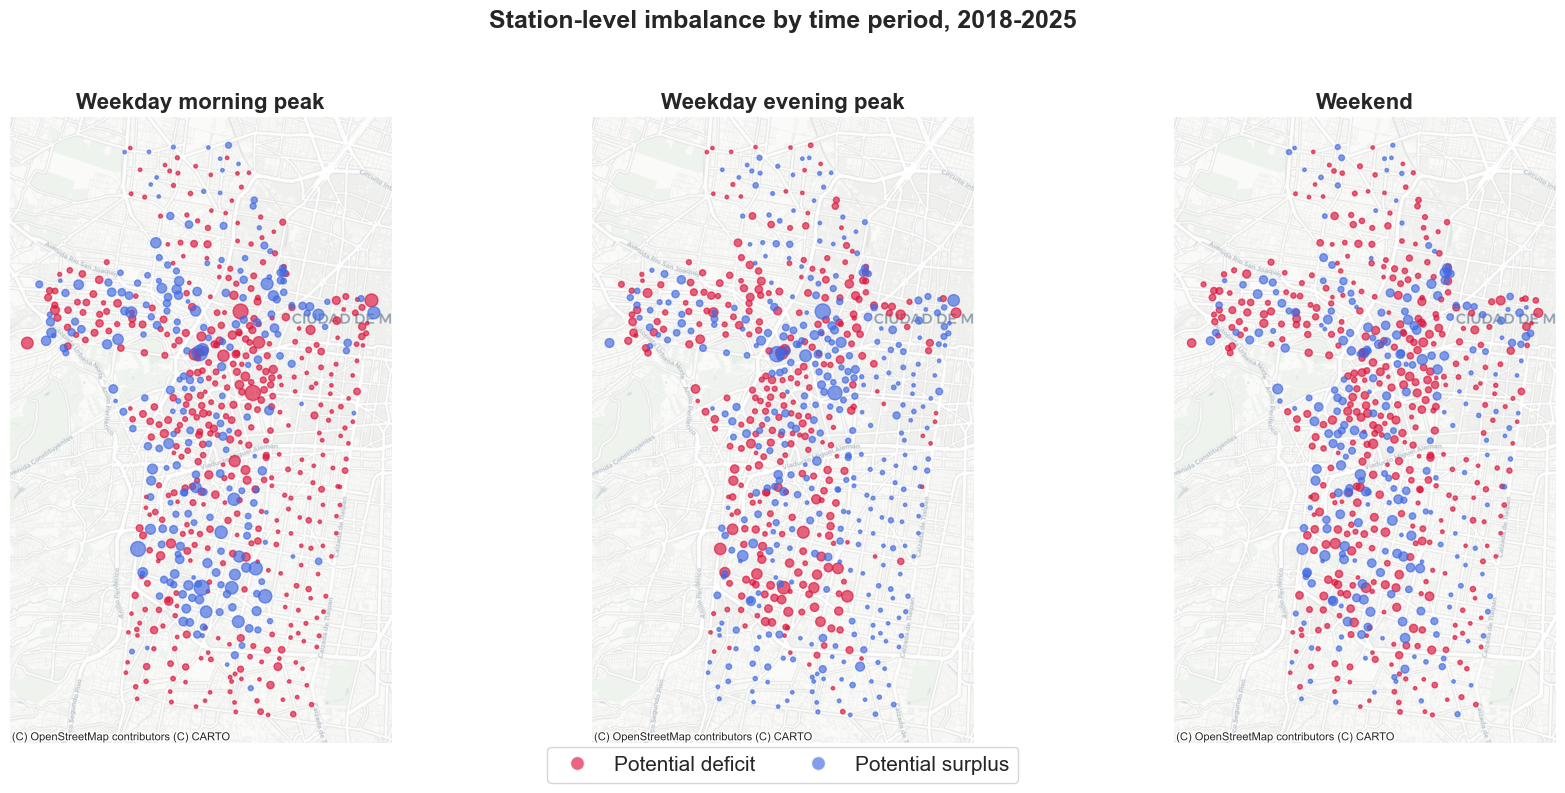

In [158]:
# Peak imbalance map (time periods)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

plot_imbalance_timeperiod_ax(
    morning_df,
    axes[0],
    "Weekday morning peak",
    stations_ref,
    global_scale=global_scale
)

plot_imbalance_timeperiod_ax(
    evening_df,
    axes[1],
    "Weekday evening peak",
    stations_ref,
    global_scale=global_scale
)

plot_imbalance_timeperiod_ax(
    weekend_df,
    axes[2],
    "Weekend",
    stations_ref,
    global_scale=global_scale
)

# one shared legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Potential deficit',
               markerfacecolor='crimson', markersize=10, alpha=0.65),
    plt.Line2D([0], [0], marker='o', color='w', label='Potential surplus',
               markerfacecolor='royalblue', markersize=10, alpha=0.65),
]

fig.legend(handles=handles, loc="lower center", ncol=2, frameon=True, fontsize=15)

fig.suptitle("Station-level imbalance by time period, 2018-2025", fontsize=18, fontweight="bold")
plt.tight_layout(rect=[0, 0.04, 1, 0.95])
plt.show()

- Here we can see that the station-level imbalance strongly related to weekday morning and evening peaks
- This concentrates in the northwest, center and southern part of the city
- The weekend station-level imbalance shows a similar pattern with with fewer trips, hence the reduced size

In [ ]:

# top 5% of stations

q = 0.95

deficit_cutoff = deficit_df["net_flow"].quantile(q)
surplus_cutoff = surplus_df["net_flow"].quantile(1 - q)  # we know surplus stations will have a negative tail

top_deficit = deficit_df[deficit_df["net_flow"] >= deficit_cutoff].copy()
top_surplus = surplus_df[surplus_df["net_flow"] <= surplus_cutoff].copy()

# leaving the rest as a muted comparison
highlight_ids = set(top_deficit["station_id"]).union(set(top_surplus["station_id"]))
rest_df = station_imbalance[~station_imbalance["station_id"].isin(highlight_ids)].copy()

In [ ]:
# what if we limited the analysis to the top 5% stations with the most imbalance?

# function for deficit and surplus mapping
def plot_top_imbalance_map(filtered_df, ax, title, stations_ref, top_pct=0.05):
    station_imbalance = (
        filtered_df.groupby("station_id")[["net_flow", "abs_net_flow"]]
        .sum()
        .reset_index()
    )

    station_imbalance["station_id"] = station_imbalance["station_id"].astype(str).str.strip()
    stations_ref = stations_ref.copy()
    stations_ref["station_id"] = stations_ref["station_id"].astype(str).str.strip()

    station_imbalance = station_imbalance.merge(
        stations_ref[["station_id", "lat", "lon"]],
        on="station_id",
        how="left"
    )

    station_imbalance = station_imbalance.dropna(subset=["lat", "lon"]).copy()

    deficit_df = station_imbalance[station_imbalance["net_flow"] > 0].copy()
    surplus_df = station_imbalance[station_imbalance["net_flow"] < 0].copy()

    deficit_cutoff = deficit_df["net_flow"].quantile(1 - top_pct) if not deficit_df.empty else np.inf
    surplus_cutoff = surplus_df["net_flow"].quantile(top_pct) if not surplus_df.empty else -np.inf

    top_deficit = deficit_df[deficit_df["net_flow"] >= deficit_cutoff].copy()
    top_surplus = surplus_df[surplus_df["net_flow"] <= surplus_cutoff].copy()

    highlight_ids = set(top_deficit["station_id"]).union(set(top_surplus["station_id"]))
    rest_df = station_imbalance[~station_imbalance["station_id"].isin(highlight_ids)].copy()

    gdf_rest = gpd.GeoDataFrame(
        rest_df,
        geometry=gpd.points_from_xy(rest_df["lon"], rest_df["lat"]),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    gdf_deficit = gpd.GeoDataFrame(
        top_deficit,
        geometry=gpd.points_from_xy(top_deficit["lon"], top_deficit["lat"]),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    gdf_surplus = gpd.GeoDataFrame(
        top_surplus,
        geometry=gpd.points_from_xy(top_surplus["lon"], top_surplus["lat"]),
        crs="EPSG:4326"
    ).to_crs(epsg=3857)

    gdf_rest.plot(
        ax=ax,
        color="lightgray",
        markersize=12,
        alpha=0.50
    )

    scale_base = station_imbalance["abs_net_flow"].quantile(0.95)
    if scale_base == 0:
        scale_base = 1

    if not gdf_deficit.empty:
        gdf_deficit.plot(
            ax=ax,
            color="crimson",
            markersize=np.clip(gdf_deficit["abs_net_flow"] / scale_base * 180, 20, 180),
            alpha=0.8
        )

    if not gdf_surplus.empty:
        gdf_surplus.plot(
            ax=ax,
            color="royalblue",
            markersize=np.clip(gdf_surplus["abs_net_flow"] / scale_base * 180, 20, 180),
            alpha=0.8
        )

    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=10)
    ax.set_axis_off()

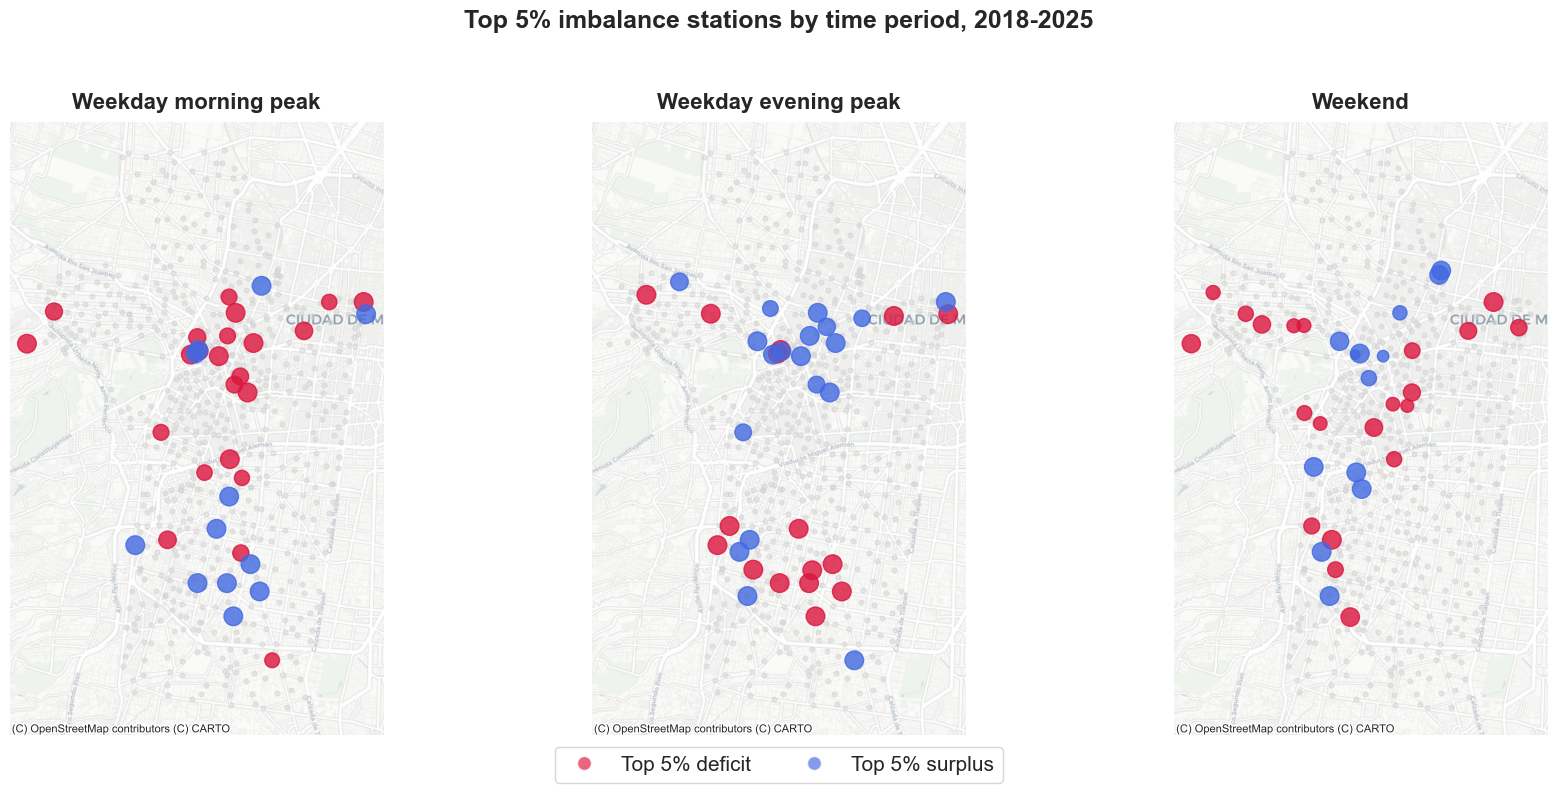

In [157]:
# Top 5% imbalance map (time periods)
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

plot_top_imbalance_map(
    morning_df,
    axes[0],
    "Weekday morning peak",
    stations_ref)

plot_top_imbalance_map(
    evening_df,
    axes[1],
    "Weekday evening peak",
    stations_ref)

plot_top_imbalance_map(
    weekend_df,
    axes[2],
    "Weekend",
    stations_ref)

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Top 5% deficit',
               markerfacecolor='crimson', markersize=10, alpha=0.65),
    plt.Line2D([0], [0], marker='o', color='w', label='Top 5% surplus',
               markerfacecolor='royalblue', markersize=10, alpha=0.65),
]

fig.legend(handles=handles, loc="lower center", ncol=2, frameon=True, fontsize=15)

fig.suptitle(
    "Top 5% imbalance stations by time period, 2018-2025",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [166]:
# summary statistics of deficit and surplus across ECOBICI:
# what % of trips take place in the top 5% of stations?

def weighted_imbalance_summary(filtered_df, label, top_pct=0.05):
    station_stats = (
        filtered_df.groupby("station_id")[["departures", "arrivals", "abs_net_flow"]]
        .sum()
        .reset_index()
    )

    threshold = station_stats["abs_net_flow"].quantile(1 - top_pct)

    top = station_stats[station_stats["abs_net_flow"] >= threshold]

    total_trips = station_stats["departures"].sum() + station_stats["arrivals"].sum()
    top_trips = top["departures"].sum() + top["arrivals"].sum()

    total_imbalance = station_stats["abs_net_flow"].sum()
    top_imbalance = top["abs_net_flow"].sum()

    return {
        "period": label,
        "n_stations": len(station_stats),
        "top_stations": len(top),
        "share_trips_top": top_trips / total_trips,
        "share_imbalance_top": top_imbalance / total_imbalance
    }

In [167]:
# what are the deficit vs. surplus volumes?

def deficit_surplus_volume(filtered_df, label):
    station_stats = (
        filtered_df.groupby("station_id")[["net_flow", "abs_net_flow"]]
        .sum()
        .reset_index()
    )

    deficit = station_stats[station_stats["net_flow"] > 0]["net_flow"].sum()
    surplus = station_stats[station_stats["net_flow"] < 0]["net_flow"].sum()

    return {
        "period": label,
        "total_deficit": deficit,
        "total_surplus": surplus,
        "abs_deficit": abs(deficit),
        "abs_surplus": abs(surplus)
    }

In [168]:
# how does the imbalance vary by year?
yearly_imbalance = (
    df.groupby(["year", "station_id"])["abs_net_flow"]
    .sum()
    .reset_index()
)

year_summary = (
    yearly_imbalance.groupby("year")["abs_net_flow"]
    .sum()
)

In [176]:
weighted_summary = pd.DataFrame([
    weighted_imbalance_summary(morning_df, "Morning"),
    weighted_imbalance_summary(evening_df, "Evening"),
    weighted_imbalance_summary(weekend_df, "Weekend"),
])

volume_summary = pd.DataFrame([
    deficit_surplus_volume(morning_df, "Morning"),
    deficit_surplus_volume(evening_df, "Evening"),
    deficit_surplus_volume(weekend_df, "Weekend"),
])

weighted_summary, volume_summary

(    period  n_stations  top_stations  share_trips_top  share_imbalance_top
 0  Morning         718            36         0.139112             0.207772
 1  Evening         718            36         0.129513             0.175575
 2  Weekend         716            36         0.179781             0.122779,
     period  total_deficit  total_surplus  abs_deficit  abs_surplus
 0  Morning        3784892       -3899419      3784892      3899419
 1  Evening        3143178       -2514977      3143178      2514977
 2  Weekend         483914        -484869       483914       484869)

Top 5% station flows:
- A small subset of stations (5% or 36 stations) accounts for 14% and 13% of demand and 20% of morning and 17% of evening imbalance; this shows that imbalance is more concentrated than demand in only those stations.
- Weekend trips behave differently, with demand being more concentrated, but imbalance being more diffuse (12%), which could be explained by the leisure nature of trips, as we know most ECOBICI users commute to work.


Deficit and surplus analysis:
- At the aggregate level, we see that absolute deficit (3.78m) and absolute surplus (3.89m) are nearly equal, with surplus having a tail as expected, due to the 1-q nature of the tail of the imbalance.

In [180]:
# when taking a year by year view, does imbalance behave differently across expansion phases?

def yearly_full_summary(df, top_pct=0.05):
    results = []

    for year, temp in df.groupby("year"):
        station_stats = (
            temp.groupby("station_id")[["departures", "arrivals", "net_flow", "abs_net_flow"]]
            .sum()
            .reset_index()
        )

        # deficit / surplus totals
        deficit = station_stats[station_stats["net_flow"] > 0]["net_flow"].sum()
        surplus = station_stats[station_stats["net_flow"] < 0]["net_flow"].sum()

        # top imbalance
        threshold = station_stats["abs_net_flow"].quantile(1 - top_pct)
        top = station_stats[station_stats["abs_net_flow"] >= threshold]

        total_imbalance = station_stats["abs_net_flow"].sum()
        top_imbalance = top["abs_net_flow"].sum()

        results.append({
            "year": year,
            "n_stations": len(station_stats),
            "total_deficit": deficit,
            "total_surplus": surplus,
            "abs_deficit": abs(deficit),
            "abs_surplus": abs(surplus),
            "top_stations": len(top),
            "share_imbalance_top": top_imbalance / total_imbalance
        })

    return pd.DataFrame(results)

In [181]:
def get_top_stations_by_year(df, top_pct=0.05):
    yearly_top = {}

    for year, temp in df.groupby("year"):
        station_stats = (
            temp.groupby("station_id")["abs_net_flow"]
            .sum()
            .reset_index()
        )

        threshold = station_stats["abs_net_flow"].quantile(1 - top_pct)

        top = station_stats[station_stats["abs_net_flow"] >= threshold]

        yearly_top[year] = set(top["station_id"])

    return yearly_top

In [185]:
top_by_year = get_top_stations_by_year(df)

years = sorted(top_by_year.keys())

overlap_matrix = pd.DataFrame(index=years, columns=years)

for y1 in years:
    for y2 in years:
        overlap = len(top_by_year[y1] & top_by_year[y2])
        overlap_matrix.loc[y1, y2] = overlap

overlap_matrix = overlap_matrix.astype(int)
overlap_matrix

,2018,2019,2020,2021,2022,2023,2024,2025
2018,25,21,15,11,15,16,12,12
2019,21,25,16,12,15,16,14,13
2020,15,16,25,18,15,13,11,8
2021,11,12,18,24,14,10,9,6
2022,15,15,15,14,25,18,13,12
2023,16,16,13,10,18,32,23,22
2024,12,14,11,9,13,23,34,28
2025,12,13,8,6,12,22,28,34


In [187]:
jaccard_matrix = pd.DataFrame(index=years, columns=years)

for y1 in years:
    for y2 in years:
        inter = len(top_by_year[y1] & top_by_year[y2])
        union = len(top_by_year[y1] | top_by_year[y2])
        jaccard_matrix.loc[y1, y2] = inter / union

jaccard_matrix = jaccard_matrix.astype(float)

In [188]:
jaccard_matrix

,2018,2019,2020,2021,2022,2023,2024,2025
2018,1.000000,0.724138,0.428571,0.289474,0.428571,0.390244,0.255319,0.255319
2019,0.724138,1.000000,0.470588,0.324324,0.428571,0.390244,0.311111,0.282609
2020,0.428571,0.470588,1.000000,0.580645,0.428571,0.295455,0.229167,0.156863
2021,0.289474,0.324324,0.580645,1.000000,0.400000,0.217391,0.183673,0.115385
2022,0.428571,0.428571,0.428571,0.400000,1.000000,0.461538,0.282609,0.255319
2023,0.390244,0.390244,0.295455,0.217391,0.461538,1.000000,0.534884,0.500000
2024,0.255319,0.311111,0.229167,0.183673,0.282609,0.534884,1.000000,0.700000
2025,0.255319,0.282609,0.156863,0.115385,0.255319,0.500000,0.700000,1.000000


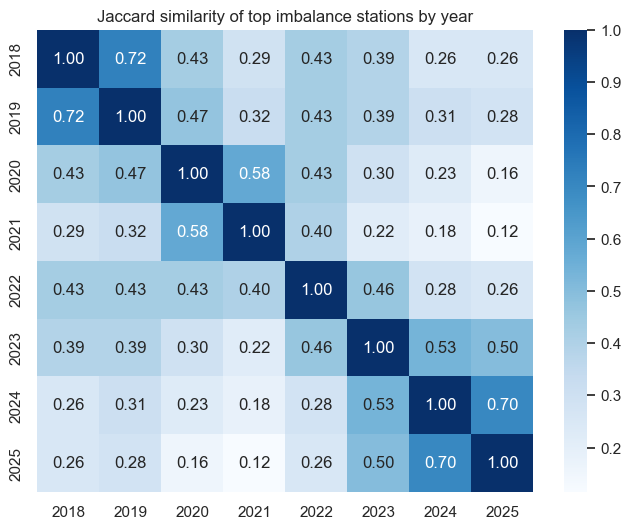

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(jaccard_matrix, annot=True, cmap="Blues", fmt=".2f")
plt.title("Jaccard similarity of top imbalance stations by year")
plt.show()